1. Conducting LR on Standard Scaled Data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Load the preprocessed dataset
df = pd.read_csv('df_EDA_standard.csv')

# 2. Separate features (X) and target variable (y)
# 'SalePrice' is the target column we want to predict
X = df.drop(columns=['SalePrice','Price_Category'])
y = df['SalePrice']

# 3. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 5. Make Predictions
y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

# 6. Evaluate the Model
def evaluate_predictions(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {dataset_name} Performance ---")
    print(f"R² Score (Variance Explained): {r2:.4f}")
    print(f"MAE (Mean Absolute Error):     {mae:.4f}")
    print(f"RMSE (Root Mean Squared Error): {rmse:.4f}\n")

evaluate_predictions(y_train, y_pred_train, "Training Set")
evaluate_predictions(y_test, y_pred_test, "Test Set")

--- Training Set Performance ---
R² Score (Variance Explained): 0.9204
MAE (Mean Absolute Error):     14414.4415
RMSE (Root Mean Squared Error): 21783.5122

--- Test Set Performance ---
R² Score (Variance Explained): 0.7473
MAE (Mean Absolute Error):     21720.0461
RMSE (Root Mean Squared Error): 44025.6671



In [16]:
# Extract coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

# Display the top 10 positive and top 5 negative drivers
print("Top Positive Drivers:\n", coefficients.head(10))
print("\nTop Negative Drivers:\n", coefficients.tail(5))

Top Positive Drivers:
               Feature    Coefficient
104  RoofMatl_WdShngl  509338.142933
102  RoofMatl_Tar&Grv  496262.175727
101     RoofMatl_Roll  494195.292524
103  RoofMatl_WdShake  493913.764353
98   RoofMatl_CompShg  489453.384554
100    RoofMatl_Metal  468088.805972
208     GarageCond_TA  167339.605073
205     GarageCond_Fa  165387.530674
206     GarageCond_Gd  159900.914201
207     GarageCond_Po  150302.338471

Top Negative Drivers:
              Feature    Coefficient
78   Condition2_PosN -168513.917842
202    GarageQual_Gd -176730.814988
204    GarageQual_TA -177449.751841
201    GarageQual_Fa -182396.107786
203    GarageQual_Po -195034.647087


Plotting Residuals

1. Training Data

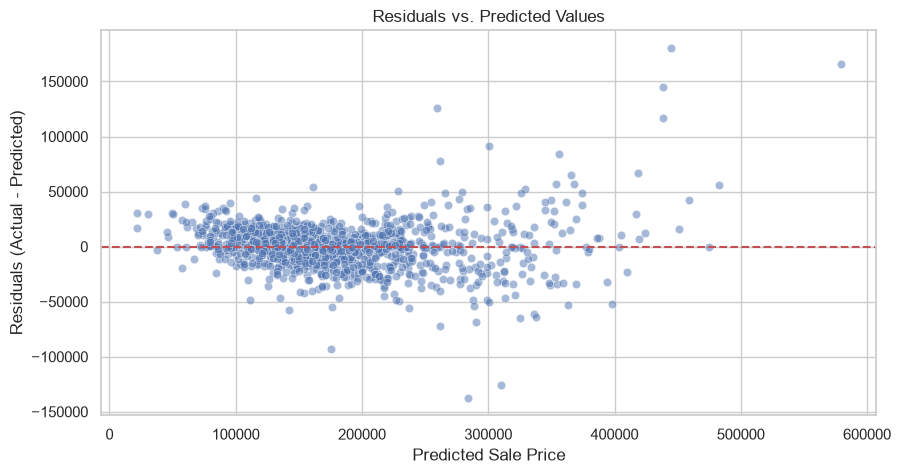

In [17]:

residuals = y_train - y_pred_train
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred_train, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs. Predicted Values')
plt.show()

2. Testing Data

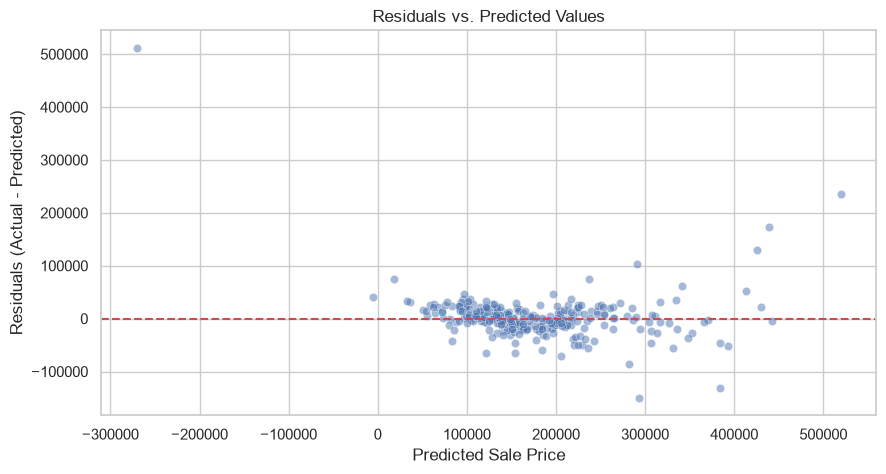

In [18]:

residuals = y_test - y_pred_test
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred_test, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs. Predicted Values')
plt.show()

Plotting the actual and predicted SalesPrice

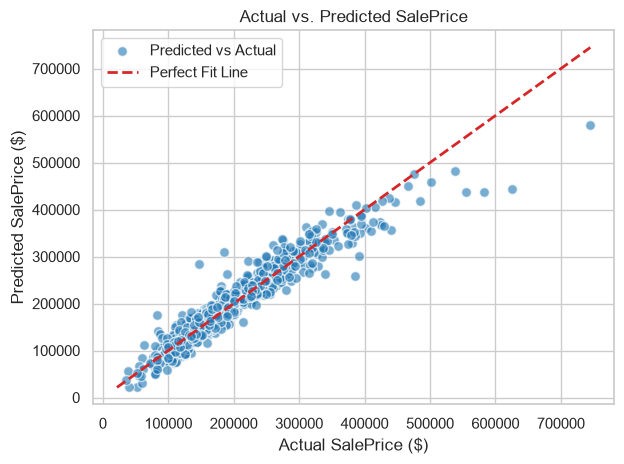

In [19]:
sns.set_theme(style='whitegrid')

plt.scatter(y_train, y_pred_train, color='#1f77b4', alpha=0.6, edgecolors='w', s=50, label='Predicted vs Actual')

# Add a 45-degree reference line representing perfect predictions
min_val = min(y_train.min(), y_pred_train.min())
max_val = max(y_train.max(), y_pred_train.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#d62728', linestyle='--', linewidth=2, label='Perfect Fit Line')

plt.title(f'Actual vs. Predicted SalePrice')
plt.xlabel('Actual SalePrice ($)', fontsize=12)
plt.ylabel('Predicted SalePrice ($)', fontsize=12)
plt.legend(frameon=True)
plt.tight_layout()

# Save the plot
plt.savefig('actual vs predicted_saleprice.png', dpi=150)
plt.show()